## Kalibrering av grundvattenmodell
*E. Haaf (Chalmers), 2026*

Denna notebook kalibrerar en grundvattenmodell med PASTAS genom att testa olika avdunstningsmetoder.

Steg:
1. Ladda in data
2. Testa alla PET-metoder i kalibrering och validering
3. Välj bästa PET-metod
4. Visa kalibreringresultat

### 0. Importera bibliotek

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pastas as ps
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error, r2_score
import os
import json

### 1. Ladda in data

In [29]:
# Sökväg till datamappen
data_mapp = "../data"

# Ladda nederbörd (m/dag)
prec = pd.read_csv(
    os.path.join(data_mapp, "precip_data_km.csv"),
    parse_dates=True, 
    index_col=0,
    date_format="%Y-%m-%d").squeeze("columns")

# Ladda temperatur (°C)
temp = pd.read_csv(
    os.path.join(data_mapp, "temp_data_km.csv"),
    parse_dates=True, 
    index_col=0,
    date_format="%Y-%m-%d").squeeze("columns")

# Ladda avdunstning (PET) - innehåller flera metoder
evap = pd.read_csv(os.path.join(data_mapp, "pet_data_km.csv"), 
                    parse_dates=True, index_col=0,
                    date_format="%Y-%m-%d").squeeze("columns")

print(f"Nederbörd: {len(prec)} dagar")
print(f"Temperatur: {len(temp)} dagar")
print(f"Avdunstning (PET): {len(evap)} dagar, {len(evap.columns)} metoder")
print(f"\nPET-metoder: {evap.columns.tolist()}")

Nederbörd: 10945 dagar
Temperatur: 10942 dagar
Avdunstning (PET): 10928 dagar, 18 metoder

PET-metoder: ['Penman', 'FAO-56', 'Priestley-Taylor', 'Kimberly-Penman', 'Thom-Oliver', 'Blaney-Criddle', 'Hamon', 'Romanenko', 'Linacre', 'Haude', 'Turc', 'Jensen-Haise', 'Mcguinness-Bordne', 'Hargreaves', 'FAO-24', 'Abtew', 'Makkink', 'Oudin']


In [30]:
# Ladda observerad grundvattenhöjd
# Ange sökvägen till filen med dagliga grundvattenobservationer
file_path = "../data/head_abs_km_compensated_daily.xlsx"
ho = pd.read_excel(file_path, usecols=[0, 1], index_col=0, parse_dates=True).squeeze()
ho.name = 'ho'

print(f"Grundvattenhöjd: {len(ho)} dagar")

Grundvattenhöjd: 806 dagar


### 2. Testa alla PET-metoder i kalibrering och validering

In [32]:
# Tidsperioder för kalibrering och validering
tmin_cal = '2022-12-22'
tmax_cal = '2024-02-19'
tmin_val = '2024-02-20'
tmax_val = '2025-02-19'

# Utökad period för hela R² beräkning
tmin_ext = tmin_cal
tmax_ext = tmax_val

# Skapa modeller för alla PET-metoder
models = []  # Lagra modeller för senare analys
pet_method_names = evap.columns.tolist()  # Hämta PET-metodnamn

for i, method_name in enumerate(pet_method_names):
    evap_selected = evap.iloc[:, i].squeeze()

    # Namn baserat på PET-metod
    model_name = f"model_{method_name}"
    ml = ps.Model(ho, name=model_name)
    
    # Lägg till rekrigningsmodell
    sm_rch = ps.RechargeModel(
        prec=prec,
        temp=temp,
        evap=evap_selected,
        rfunc=ps.Gamma(),
        name=f"rch_{method_name}",
        recharge=ps.rch.FlexModel(gw_uptake=True, snow=True)
    )
    ml.add_stressmodel(sm_rch)
    
    # Justera parametrar
    ml.set_parameter(f"rch_{method_name}_kv", vary=True)
    
    # Tvåstegs lösningsteknik
    # Steg 1
    ml.solve(
        tmin=tmin_cal,
        tmax=tmax_cal,
        fit_constant=False,
        report=False,
        solver=ps.LeastSquares()
    )
    ml.set_parameter(f"rch_{method_name}_srmax", vary=False)
    
    # Steg 2

    ml.add_noisemodel(ps.ArNoiseModel())

    ml.solve(
        tmin=tmin_cal,
        tmax=tmax_cal,
        fit_constant=False,
        initial=False,
        report=False,
        solver=ps.LeastSquares()
    )
    
    models.append(ml)

print(f"Skapade {len(models)} modeller för {len(pet_method_names)} PET-metoder")

The Time Series 'Prec' has nan-values. Pastas will use the fill_nan settings to fill up the nan-values.
The Time Series 'Temp' has nan-values. Pastas will use the fill_nan settings to fill up the nan-values.
The Time Series 'Prec' has nan-values. Pastas will use the fill_nan settings to fill up the nan-values.
The Time Series 'Temp' has nan-values. Pastas will use the fill_nan settings to fill up the nan-values.
The Time Series 'Prec' has nan-values. Pastas will use the fill_nan settings to fill up the nan-values.
The Time Series 'Temp' has nan-values. Pastas will use the fill_nan settings to fill up the nan-values.
The Time Series 'Prec' has nan-values. Pastas will use the fill_nan settings to fill up the nan-values.
The Time Series 'Temp' has nan-values. Pastas will use the fill_nan settings to fill up the nan-values.
The Time Series 'Prec' has nan-values. Pastas will use the fill_nan settings to fill up the nan-values.
The Time Series 'Temp' has nan-values. Pastas will use the fill_

Skapade 18 modeller för 18 PET-metoder


### 3. Evaluera alla modeller och visualisera resultaten

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.

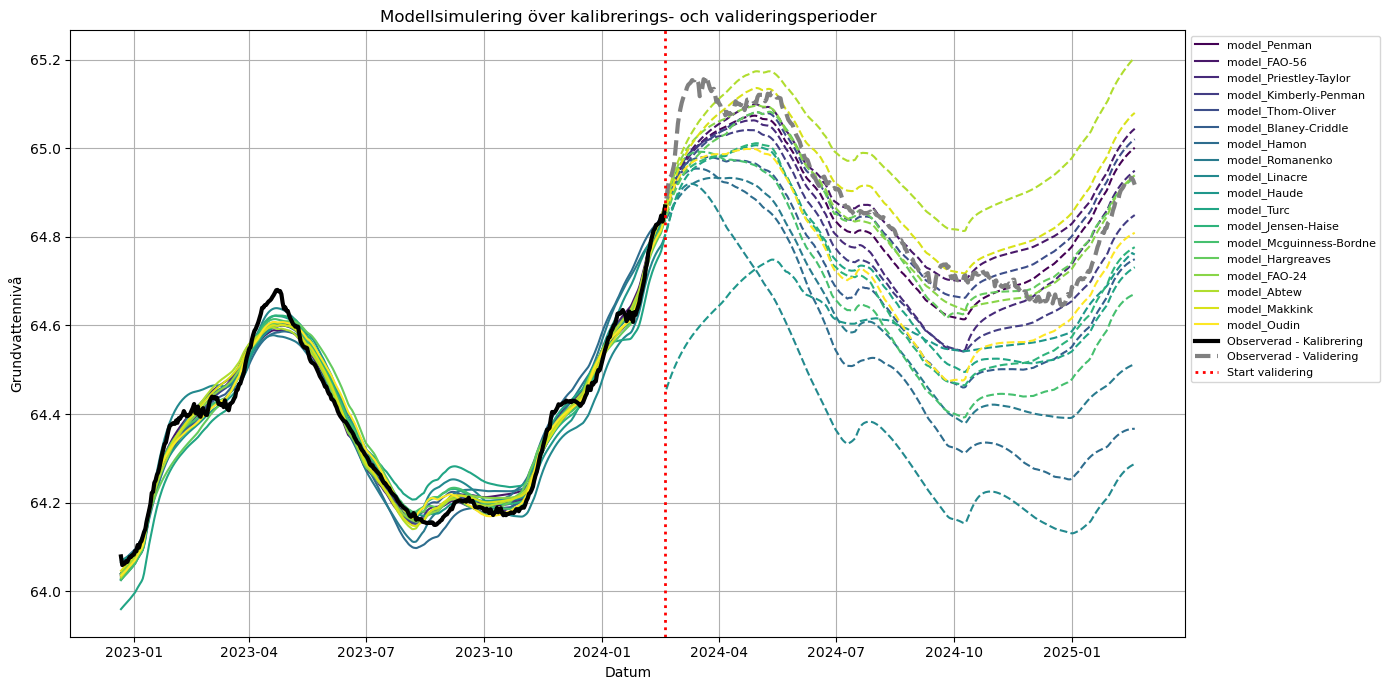


R² värden för varje modell över kalibrerings-, validerings- och utökad period:
                     Modell  R2_Kalibrering  R2_Validering  R2_Utökad
0              model_Penman          0.9819         0.8083     0.9726
1              model_FAO-56          0.9750         0.7756     0.9552
2    model_Priestley-Taylor          0.9796         0.7003     0.9578
3     model_Kimberly-Penman          0.9831         0.6052     0.9433
4         model_Thom-Oliver          0.9804         0.8119     0.9682
5      model_Blaney-Criddle          0.9816        -0.0990     0.8402
6               model_Hamon          0.9467        -3.1728     0.3893
7           model_Romanenko          0.9534        -1.5140     0.6290
8             model_Linacre          0.9550        -7.0377    -0.1644
9               model_Haude          0.9681        -1.8648     0.7839
10               model_Turc          0.9151         0.1548     0.8633
11       model_Jensen-Haise          0.9788         0.0826     0.8704
12  model_

In [ ]:
# Förbered DataFrame för R² värden
r2_results = pd.DataFrame(columns=["Modell", "R2_Kalibrering", "R2_Validering", "R2_Utökad"])

# Skapa figur
fig, ax = plt.subplots(figsize=(14, 7))

# Färgpalett
colors = plt.cm.viridis(np.linspace(0, 1, len(models)))

# Loop genom modeller för simulering och plottning
for idx, model in enumerate(models):
    # Kalibreringperiod
    sim_cal = model.simulate(tmin=tmin_cal, tmax=tmax_cal)
    obs_cal = ho[tmin_cal:tmax_cal]
    r2_cal = r2_score(obs_cal, sim_cal)

    # Valideringsperiod
    sim_val = model.simulate(tmin=tmin_val, tmax=tmax_val)
    obs_val = ho[tmin_val:tmax_val]
    r2_val = r2_score(obs_val, sim_val)

    # Hela perioden
    sim_ext = model.simulate(tmin=tmin_ext, tmax=tmax_ext)
    obs_ext = ho[tmin_ext:tmax_ext]
    r2_ext = r2_score(obs_ext, sim_ext)

    # Lagra R² resultaten
    r2_row = pd.DataFrame([{
        "Modell": model.name,
        "R2_Kalibrering": r2_cal,
        "R2_Validering": r2_val,
        "R2_Utökad": r2_ext
    }])
    r2_results = pd.concat([r2_results, r2_row], ignore_index=True)
    
    # Plotta resultat
    ax.plot(sim_cal.index, sim_cal, label=f"{model.name}", color=colors[idx])
    ax.plot(sim_val.index, sim_val, linestyle='--', color=colors[idx])

# Plotta observerade data
ax.plot(obs_cal.index, obs_cal, color='black', linewidth=3, label="Observerad - Kalibrering")
ax.plot(obs_val.index, obs_val, color='grey', linewidth=3, label="Observerad - Validering", linestyle='--')

# Markera övergång från kalibrering till validering
ax.axvline(x=pd.Timestamp(tmax_cal), color='red', linestyle=':', linewidth=2, label='Start validering')

# Formatera plot
ax.set_title('Modellsimulering över kalibrerings- och valideringsperioder')
ax.set_xlabel('Datum')
ax.set_ylabel('Grundvattennivå')
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), ncol=1, fontsize=8)
ax.grid(True)

plt.tight_layout()
plt.show()

# Skriv ut R² resultaten
print("\nR² värden för varje modell över kalibrerings-, validerings- och hela perioden:")
pd.options.display.float_format = '{:,.4f}'.format
print(r2_results)

### 3. Välj bästa PET-metod

In [34]:
# Visa alla PET-metodnamn
print("Tillgängliga PET-metoder:")
for i, method_name in enumerate(pet_method_names, 1):
    r2_info = r2_results[r2_results['Modell'] == f'model_{method_name}']
    if not r2_info.empty:
        r2_val = r2_info['R2_Validering'].values[0]
        r2_cal = r2_info['R2_Kalibrering'].values[0]
        print(f"{i}. {method_name:30s} | R² Kalibrering: {r2_cal:.4f} | R² Validering: {r2_val:.4f}")
    else:
        print(f"{i}. {method_name}")

Tillgängliga PET-metoder:
1. Penman                         | R² Kalibrering: 0.9819 | R² Validering: 0.8083
2. FAO-56                         | R² Kalibrering: 0.9750 | R² Validering: 0.7756
3. Priestley-Taylor               | R² Kalibrering: 0.9796 | R² Validering: 0.7003
4. Kimberly-Penman                | R² Kalibrering: 0.9831 | R² Validering: 0.6052
5. Thom-Oliver                    | R² Kalibrering: 0.9804 | R² Validering: 0.8119
6. Blaney-Criddle                 | R² Kalibrering: 0.9816 | R² Validering: -0.0990
7. Hamon                          | R² Kalibrering: 0.9467 | R² Validering: -3.1728
8. Romanenko                      | R² Kalibrering: 0.9534 | R² Validering: -1.5140
9. Linacre                        | R² Kalibrering: 0.9550 | R² Validering: -7.0377
10. Haude                          | R² Kalibrering: 0.9681 | R² Validering: -1.8648
11. Turc                           | R² Kalibrering: 0.9151 | R² Validering: 0.1548
12. Jensen-Haise                   | R² Kalibrering: 0

In [35]:
# Val av PET-metod för visning av kalibreringresultat
evap_choice = input("Ange namn på metoden som ska användas: ") # FAO-24

# Kontrollera om metoden finns
if evap_choice in evap:
    evap_selected = evap[evap_choice]
    print(f"Vald metod: {evap_choice}")
else:
    print(f"Metoden {evap_choice} hittades inte. Kontrollera stavningen.")

Vald metod: FAO-24


### 4. Visa kalibreringresultat

The Time Series 'Prec' has nan-values. Pastas will use the fill_nan settings to fill up the nan-values.
The Time Series 'Temp' has nan-values. Pastas will use the fill_nan settings to fill up the nan-values.


[<Axes: xlabel='Date/time', ylabel='Head'>,
 <Axes: xlabel='Date/time'>,
 <Axes: title={'right': "Stresses: ['Prec', 'FAO-24', 'Temp']"}, xlabel='Datum', ylabel='Rise'>,
 <Axes: title={'center': 'Step response'}, xlabel='Time [days]'>,
 <Axes: title={'left': 'Model Parameters ($n_c$=10)'}>]

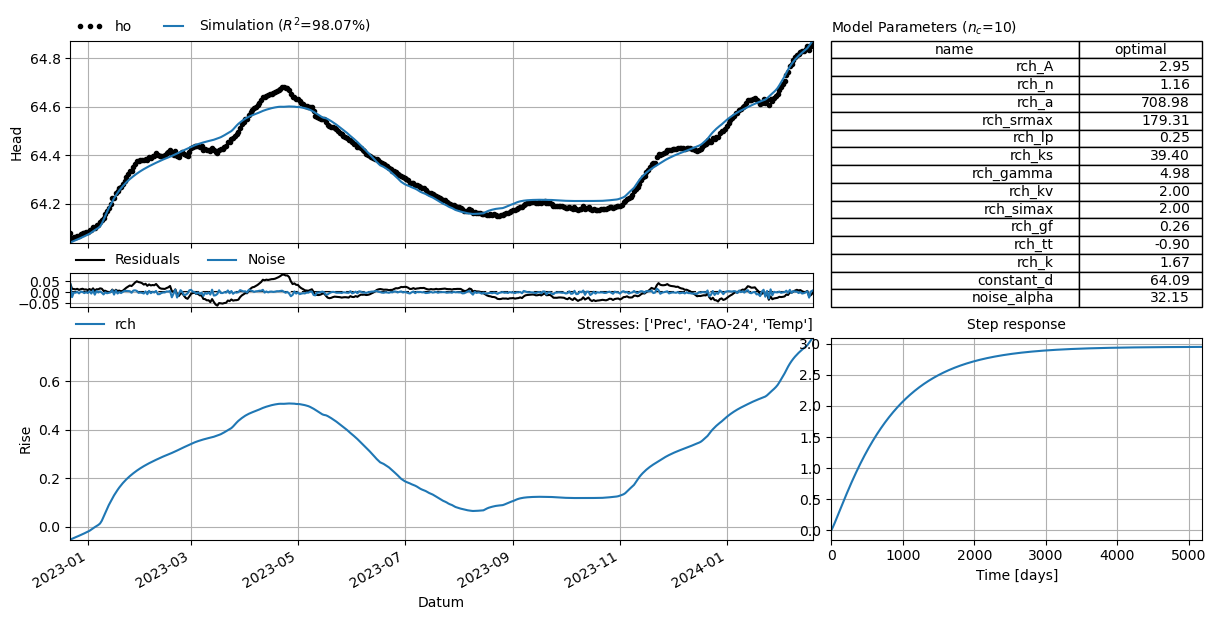

In [37]:
# Skapa slutgiltig modell med vald PET-metod

# Tidsperiod för kalibrering
tmin = tmin_cal
tmax = tmax_cal

# Skapa modellobjekt
gw_model = ps.Model(ho, name="my_model")

# Välj grundvattenbildningsmodell
rm1 = ps.rch.FlexModel(
    gw_uptake=True,
    snow=True
)

sm1 = ps.RechargeModel(
    prec,
    evap_selected,
    temp=temp,
    recharge=rm1,
    rfunc=ps.Gamma(),
    name="rch"
)

gw_model.add_stressmodel(sm1)

# Justera parametrar - variera k_v eftersom avdunstningen är grov uppskattning
gw_model.set_parameter("rch_kv", vary=True)

# TVÅSTEGS LÖSNINGSTEKNIK
# Steg 1
gw_model.solve(
    tmin=tmin,
    tmax=tmax,
    fit_constant=False,
    report=False,
    solver=ps.LeastSquares()
)

gw_model.set_parameter("rch_srmax", vary=False)

gw_model.add_noisemodel(ps.ArNoiseModel())

# Steg 2
gw_model.solve(
    tmin=tmin,
    tmax=tmax,
    fit_constant=False,
    initial=False,
    report=False,
    solver=ps.LeastSquares()
)

# Visa kalibreringresultaten
gw_model.plots.results(figsize=(12, 6))

### 5. Exportera modelparametrar för senare körning

In [ ]:
# Spara kalibreringsinställningar i ../data
output_dir = "../data"
os.makedirs(output_dir, exist_ok=True)

safe_method = "".join(ch if ch.isalnum() or ch in ("-", "_") else "_" for ch in evap_choice)
settings_path = os.path.join(output_dir, f"kalibrering_settings_{safe_method}.json")
params_path = os.path.join(output_dir, f"kalibrering_parameters_{safe_method}.csv")

selected_row = r2_results.loc[r2_results["Modell"] == f"model_{evap_choice}"]
r2_cal_selected = None
r2_val_selected = None
r2_ext_selected = None
if not selected_row.empty:
    r2_cal_selected = float(selected_row["R2_Kalibrering"].iloc[0])
    r2_val_selected = float(selected_row["R2_Validering"].iloc[0])
    r2_ext_selected = float(selected_row["R2_Utökad"].iloc[0])

settings = {
    "well_id": "22S107GU",
    "model_name": gw_model.name,
    "selected_pet_method": evap_choice,
    "calibration_period": {"tmin": tmin_cal, "tmax": tmax_cal},
    "validation_period": {"tmin": tmin_val, "tmax": tmax_val},
    "model_structure": {
        "rfunc": "Gamma",
        "recharge_model": "FlexModel",
        "gw_uptake": True,
        "snow": True,
        "stressmodel_name": "rch"
    },
    "scores": {
        "r2_calibration": r2_cal_selected,
        "r2_validation": r2_val_selected,
        "r2_extended": r2_ext_selected
    },
    "parameter_file": os.path.basename(params_path)
}

with open(settings_path, "w", encoding="utf-8") as f:
    json.dump(settings, f, ensure_ascii=False, indent=2)

gw_model.parameters.to_csv(params_path)

print(f"Inställningar sparade: {settings_path}")
print(f"Parametrar sparade: {params_path}")
print(gw_model.parameters.head())

Inställningar sparade: ../data\kalibrering_settings_FAO-24.json
Parametrar sparade: ../data\kalibrering_parameters_FAO-24.csv
           initial   pmin        pmax   vary name     dist   stderr  optimal
rch_A       3.6130 0.0000     46.9518   True  rch  uniform   3.0552   2.9525
rch_n       1.1055 0.0100    100.0000   True  rch  uniform   0.0690   1.1590
rch_a     953.8444 0.0100 10,000.0000   True  rch  uniform 750.6261 708.9846
rch_srmax 179.3122 0.0000  1,000.0000  False  rch  uniform      NaN 179.3122
rch_lp      0.2500 0.0000      1.0000  False  rch  uniform      NaN   0.2500
